Question 1: What is a Decision Tree, and how does it work in the context of classification?

Answer:
A Decision Tree is a non-parametric supervised learning algorithm used for both classification and regression. In the context of classification, it works by breaking down a dataset into smaller and smaller subsets based on specific features, eventually forming a structure that looks like an inverted tree.

The Step-by-Step Process
A Decision Tree makes decisions by asking a series of binary questions (Yes/No) about the features of the data.

1. Starting at the Root Node
The process begins at the top (the Root Node), which contains the entire dataset. The algorithm looks for the feature that best splits the data into the most "pure" groups.

2. Splitting via Feature Selection
To decide which feature to split on, the tree uses mathematical criteria like Gini Impurity or Information Gain (Entropy).

->Goal: Maximize "purity." If a split results in a group where 100% of the items belong to a single class, that split is perfect.

3. Internal Nodes (Decision Points)
If a subset is not yet pure, it becomes an Internal Node. The algorithm repeats the splitting process for this node, choosing the next best feature to divide the remaining data.

4. Reaching the Leaf Nodes
The process continues until one of three things happens:

->All data points in a node belong to the same class.

->There are no more features left to split on.

->The tree reaches a pre-defined limit (like a maximum depth).These final endpoints are called Leaf Nodes, and they represent the final predicted class (e.g., "Buy" vs. "Don't Buy" or "Spam" vs. "Not Spam").

Question 2: Explain the concepts of Gini Impurity and Entropy as impurity measures. How do they impact the splits in a Decision Tree?

Answer:
1. Gini Impurity
->Gini Impurity measures the probability of a randomly chosen element being incorrectly classified if it was randomly labeled according to the distribution of labels in the subset.

->The Formula: $G = 1 - \sum_{i=1}^{n} P_i^2$

->Range: It ranges from 0 to 0.5 (for a 2-class problem).

->Interpretation: * 0: Perfect purity (all elements belong to one class).0.5: Maximum impurity (elements are distributed 50/50 between two classes).

->Characteristic: Gini is computationally faster because it doesn't involve logarithmic calculations. It is the default metric used by Scikit-Learn's DecisionTreeClassifier.

2. Entropy
->Entropy is a concept borrowed from information theory that measures the "disorder" or randomness in a set of data.

->The Formula: $E = -\sum_{i=1}^{n} P_i \log_2(P_i)$

->Range: It ranges from 0 to 1.

->Interpretation:0: No disorder (perfectly pure).1: Maximum disorder (perfectly random/mixed).

->Information Gain: When using Entropy, the algorithm calculates Information Gain, which is the decrease in entropy after a dataset is split. The tree chooses the split that results in the highest Information Gain.

How They Impact Splits:
Both measures serve the same purpose: guiding the algorithm to find the "best" feature and "best" threshold to divide the data.

The Search for Purity
The algorithm iterates through every feature (e.g., Area, Rooms, Price) and every possible split point. It calculates the Gini or Entropy for the resulting child nodes. It selects the split that results in the lowest weighted average impurity for the children.

Decision Boundaries
->Gini tends to isolate the largest class into its own branch.

->Entropy tends to produce more balanced trees because it is more sensitive to changes in the node probabilities.

Comparision
| Feature | Gini Impurity | Entropy |
| :--- | :--- | :--- |
| **Mathematical Complexity** | Low (Squaring only) | High (Logarithmic) |
| **Computation Speed** | Faster | Slower |
| **Standard Range** | 0 to 0.5 | 0 to 1 |
| **Usage** | Default in Scikit-Learn | Common in ID3 and C4.5 algorithms |

Question 3: What is the difference between Pre-Pruning and Post-Pruning in Decision Trees? Give one practical advantage of using each.

1. Pre-Pruning (Early Stopping)

Pre-Pruning stops the growth of the decision tree during the construction phase. You set specific "stopping criteria" that the algorithm checks at every potential split. If a split does not meet the criteria, the node is turned into a leaf immediately.

How it works: It uses hyperparameters to constrain the tree.

Common Hyperparameters (in Scikit-Learn):

->max_depth: Limits the number of levels.

->min_samples_split: Minimum samples required to attempt a split.

->min_samples_leaf: Minimum samples allowed in a final leaf.

Practical Advantage:

Computational Efficiency: Because the tree stops growing early, it saves significant time and memory. This makes it the preferred choice for large-scale datasets where building a full, unconstrained tree would be computationally expensive.

2. Post-Pruning (Cost Complexity Pruning)

Post-Pruning allows the tree to grow to its fullest extent (until all leaves are pure or no more splits are possible) and then "trims" back branches that do not significantly improve the model's accuracy on a validation set.

How it works: The algorithm builds a complete, likely overfitted tree. It then moves from the bottom up, evaluating sub-trees. If removing a sub-tree and replacing it with a leaf doesn't significantly hurt performance, the branch is removed.

Common Technique: Cost Complexity Pruning ($\alpha$): This uses a parameter (called ccp_alpha) to find a mathematical balance between the number of leaves and the error rate.

Practical Advantage:

Capturing Complex Relationships: Decision trees are "greedy"—they make the best split now without looking ahead. Pre-pruning might stop a split that looks weak but leads to highly informative splits further down. Post-pruning allows these "hidden" patterns to be discovered before deciding what to trim.

Key Differences at a Glance
| Feature | Pre-Pruning | Post-Pruning |
| :---- | :---- | :---- |
| **Timing** | During tree construction (top-down). | After the tree is fully grown (bottom-up). |
| **Approach** | Proactive / Preventive. | Reactive / Corrective. |
| **Risk** | Risk of **Underfitting** (stopping too soon). | Risk of initial high memory/CPU usage. |
| **Complexity** | Simple to implement with hyperparameters. | More complex; requires validation or tuning. |


Question 4: What is Information Gain in Decision Trees, and why is it important for choosing the best split?

Answer:Information Gain (IG) is a statistical property that measures how well a given attribute separates the training examples according to their target classification. It is the primary criteria used by algorithms like ID3 to determine which feature to split on at each step in the tree.

1. The Foundation: Entropy

Before defining Information Gain, we must understand Entropy. In information theory, Entropy is a measure of "disorder" or uncertainty in a dataset.

If a dataset $S$ contains examples from $c$ different classes, the entropy $H(S)$ is calculated as:

$$H(S) = \sum_{i=1}^{c} -p_i \log_2(p_i)$$

Where:

$p_i$ is the proportion of examples belonging to class $i$.

Entropy = 0: The node is "Pure" (all examples belong to one class).

Entropy = 1: The node is "Perfectly Impure" (examples are evenly split, e.g., 50/50).

2. Defining Information Gain

Information Gain is the reduction in entropy achieved by partitioning a dataset according to a specific feature. It calculates the difference between the entropy of the parent node and the weighted average entropy of the child nodes.

The formula for Information Gain for a feature $A$ on dataset $S$ is:

$$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$$

Where:

$H(S)$ is the entropy of the parent node.

$Values(A)$ are all possible values of feature $A$.

$S_v$ is the subset of $S$ for which feature $A$ has value $v$.

$\frac{|S_v|}{|S|}$ is the weight of the child node (ratio of samples in child vs parent).

3. Why is it Important for Choosing the Best Split?

Information Gain acts as the "Selection Engine" of the decision tree. It is important for the following reasons:

A. Maximizing Purity

The algorithm calculates the IG for every available feature. It chooses the feature with the highest Information Gain to be the split point. A high IG means that the resulting child nodes are much "cleaner" (lower entropy) than the parent, bringing the tree closer to a final classification.

B. Efficiency and Tree Depth

By choosing the most informative features first (those that reduce uncertainty the most), the algorithm creates a more compact tree. This helps in:

->Faster Inference: Shorter paths from root to leaf.

->Better Generalization: Preventing the tree from growing unnecessarily deep and complex.

C. Feature Importance

Information Gain provides a natural way to rank features. Features used at the top of the tree (near the Root Node) have the highest IG and are considered the most powerful predictors in the dataset.

4. The Limitation: High Cardinality Bias

->One major drawback of Information Gain is that it tends to prefer features with a large number of unique values (high cardinality).

->Example: If you split on a Customer_ID column, every child node would have only 1 sample and an entropy of 0. This results in a "perfect" Information Gain, but the split is useless for predicting new data.

->The Fix: To solve this, advanced algorithms use Gain Ratio, which penalizes features with too many branches.

Question 5: What are some common real-world applications of Decision Trees, and what are their main advantages and limitations?

1. Real-World Applications

A. Finance and Banking

->Credit Scoring: Banks use decision trees to determine the creditworthiness of loan applicants. By analyzing features like income, age, and employment history, the tree classifies an applicant as "High Risk" or "Low Risk."

->Fraud Detection: Identifying fraudulent credit card transactions by checking patterns such as transaction amount, location, and frequency.

B. Healthcare and Medicine

->Disease Diagnosis: Clinicians use decision trees to diagnose patients based on symptoms and test results. For example, "If Fever > 101 AND Cough = Yes, THEN test for Influenza."

->Patient Outcome Prediction: Predicting the likelihood of a patient responding to a specific treatment plan.

C. Marketing and Sales

->Customer Segmentation: Grouping customers based on purchasing behavior and demographics to tailor marketing campaigns.

->Churn Prediction: Identifying which customers are likely to cancel a subscription based on their usage patterns and support tickets.

D. Manufacturing (Relevant to Bosch)

->Fault Diagnosis: Analyzing sensor data from machinery to identify the root cause of a failure (e.g., in FOTA cycles or ECU testing).

->Quality Control: Classifying products as "Pass" or "Fail" based on measurement features during the production line.

2. Main Advantages

->Interpretability (White-Box Model): The logic of a decision tree is easy to visualize and explain to non-technical stakeholders. You can follow the path from the root to the leaf to understand exactly why a decision was made.

->No Data Scaling Required: Unlike Linear Regression or SVMs, decision trees do not require feature scaling (normalization or standardization) because they split data based on thresholds, not distances.

->Handles Mixed Data Types: They can process both numerical data (e.g., Price) and categorical data (e.g., Color) without extensive preprocessing.

->Captures Non-Linear Relationships: Decision trees can naturally model complex non-linear interactions between features without needing to transform the data.

3. Main Limitations

->Overfitting (High Variance): Without pruning, decision trees tend to grow until they have "memorized" every noise and outlier in the training data, leading to poor performance on new data.

->Instability: A small change in the training data can result in a completely different tree structure. This makes individual trees less reliable than ensemble methods.

->Greedy Nature: The algorithm makes the best possible split at each step (local optimum) but does not look ahead to see if a different split might lead to a better overall tree (global optimum).

->Bias toward High Cardinality: As seen in your previous files, Information Gain naturally prefers features with many unique values (like Customer_ID), which can lead to meaningless splits.

Question 6: Write a Python program to:
● Load the Iris Dataset
● Train a Decision Tree Classifier using the Gini criterion
● Print the model’s accuracy and feature importances

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris

#Loading the dataset
iris_data=load_iris()
print(iris_data.DESCR)
x=pd.DataFrame(iris_data.data,columns=iris_data.feature_names)
y=iris_data.target

#Perfrom train test split
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

#Creating a decision tree
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(criterion='gini')
model.fit(x_train,y_train)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

DecisionTreeClassifier()

In [20]:
#Testing the data 
y_pred=model.predict(x_test)

#Checking accuracy of the model
from sklearn.metrics import accuracy_score,classification_report

print('The accuracy score of the model is :',accuracy_score(y_test,y_pred))
print('The classification report of the model is :',classification_report(y_test,y_pred))

The accuracy score of the model is : 0.9555555555555556
The classification report of the model is :               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.94      0.94        18
           2       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



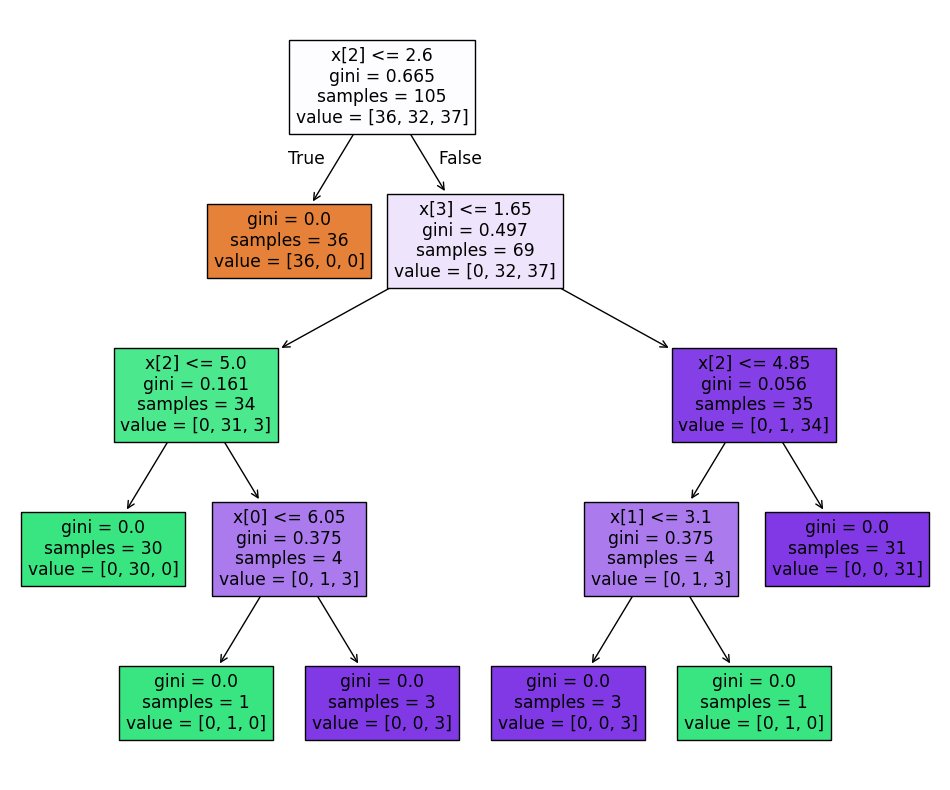

In [21]:
#The decision tree
from sklearn import tree
plt.figure(figsize=(12,10))
tree.plot_tree(model,filled=True)
plt.show()

Question 7: Write a Python program to:
● Load the Iris Dataset
● Train a Decision Tree Classifier with max_depth=3 and compare its accuracy to a fully-grown tree.

In [22]:
#Train the decision tree
model=DecisionTreeClassifier(max_depth=3)
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [23]:
#Testing the data 
y_pred=model.predict(x_test)

#Checking accuracy of the model
from sklearn.metrics import accuracy_score,classification_report

print('The accuracy score of the model is :',accuracy_score(y_test,y_pred))
print('The classification report of the model is :',classification_report(y_test,y_pred))

The accuracy score of the model is : 0.9555555555555556
The classification report of the model is :               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.94      0.94        18
           2       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



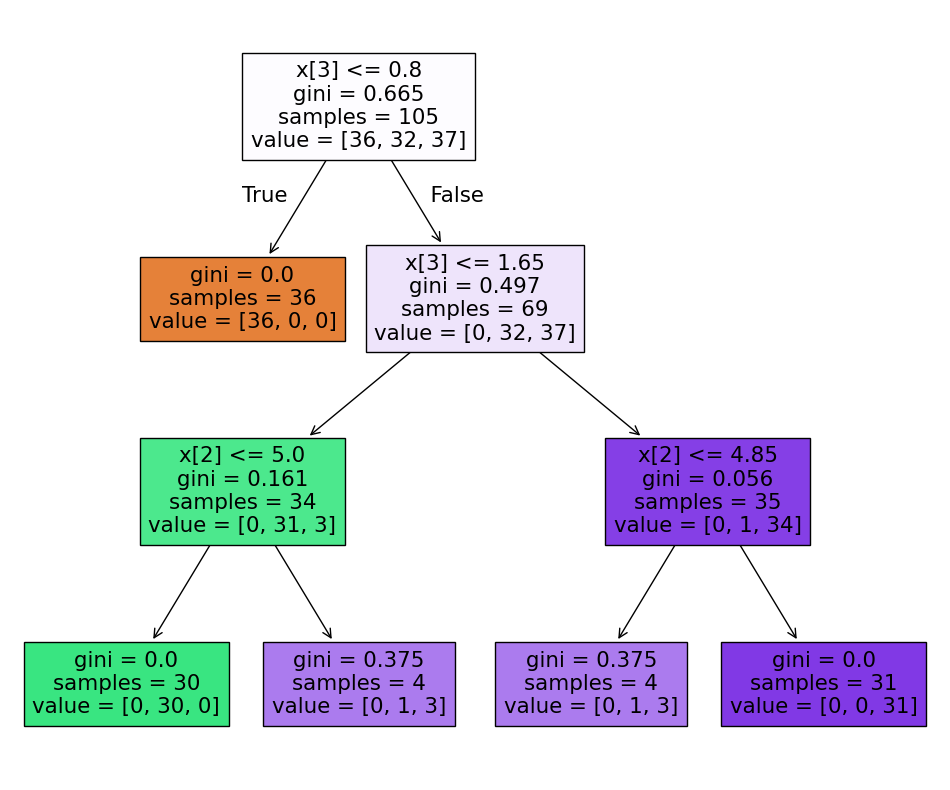

In [24]:
plt.figure(figsize=(12,10))
tree.plot_tree(model,filled=True)
plt.show()

Question 8: Write a Python program to:
● Load the Boston Housing Dataset
● Train a Decision Tree Regressor
● Print the Mean Squared Error (MSE) and feature importances

In [25]:
# We fetch by name. 'version=1' is the standard Boston dataset.
# as_frame=True automatically returns a Pandas DataFrame.
from sklearn.datasets import fetch_openml

boston=fetch_openml(name='boston',version=1,as_frame=True,parser='auto')

# Extract the data and target
df=boston.frame
print(boston.DESCR)
df.head()

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic
prices and the demand for clean air', J. Environ. Economics & Management,
vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics
...', Wiley, 1980.   N.B. Various transformations are used in the table on
pages 244-261 of the latter.
Variables in order:
CRIM     per capita crime rate by town
ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS    proportion of non-retail business acres per town
CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
NOX      nitric oxides concentration (parts per 10 million)
RM       average number of rooms per dwelling
AGE      proportion of owner-occupied units built prior to 1940
DIS      weighted distances to five Boston employment centres
RAD      index of accessibility to radial highways
TAX      full-value property-tax rate per $10

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [26]:
#Splitting the data into x and y
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

#Splitting into train and test
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

In [27]:
#Training the model
from sklearn.tree import DecisionTreeRegressor

model=DecisionTreeRegressor()

model.fit(x_train,y_train)


DecisionTreeRegressor()

In [28]:
#Testing the data
y_pred=model.predict(x_test)
#Predicting the score
from sklearn.metrics import mean_squared_error

print('The mean squared error of model is :',mean_squared_error(y_test,y_pred))
print('The feature importance of model is :',model.feature_importances_)

The mean squared error of model is : 16.331184210526317
The feature importance of model is : [0.01902663 0.00116655 0.00110799 0.00299852 0.02847839 0.24915643
 0.01086595 0.08458978 0.00898853 0.00767958 0.00873966 0.02328099
 0.55392099]


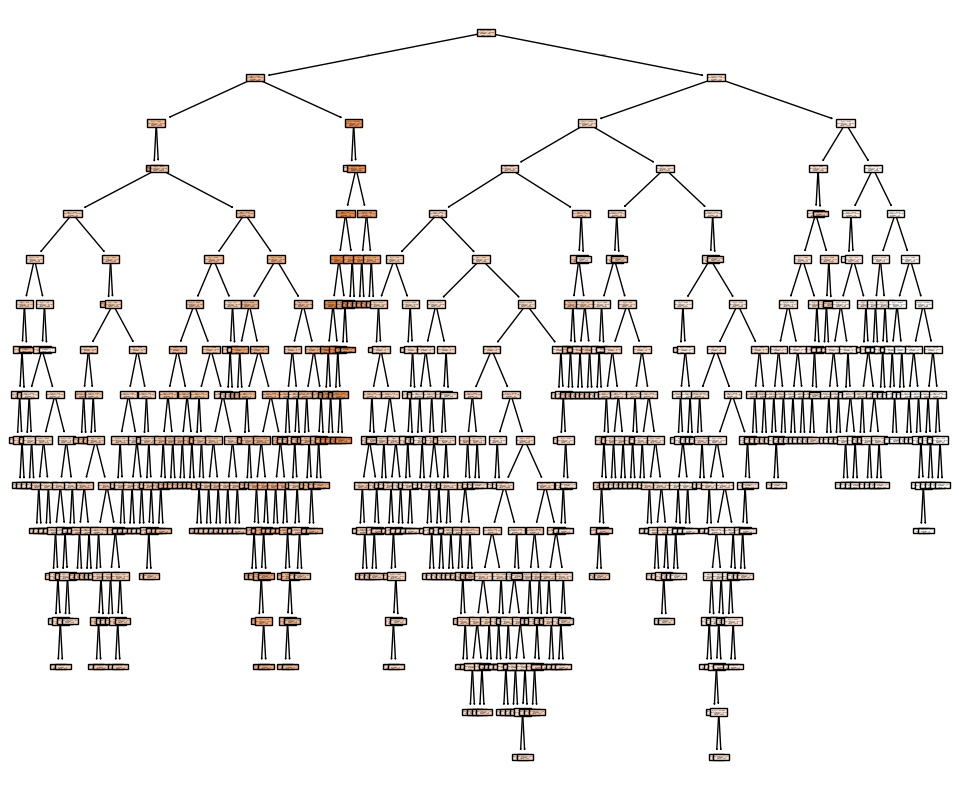

In [29]:
#The decision tree
from sklearn import tree
plt.figure(figsize=(12,10))
tree.plot_tree(model,filled=True)
plt.show()

Question 9: Write a Python program to:
● Load the Iris Dataset
● Tune the Decision Tree’s max_depth and min_samples_split using GridSearchCV
● Print the best parameters and the resulting model accuracy

In [30]:
from sklearn.datasets import load_iris

#Loading the dataset
iris_data=load_iris()
print(iris_data.DESCR)
x=pd.DataFrame(iris_data.data,columns=iris_data.feature_names)
y=iris_data.target

#Perfrom train test split
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

#Define the parameter grid for tuning
param_grid={'max_depth':[2,3,4,5,6,None],
        'min_samples_split':[2,5,10,20],
        'criterion':['gini','entropy']}

#Creating a decision tree
model=DecisionTreeClassifier()

from sklearn.model_selection import GridSearchCV
#Hyperparameter tuning
gsv=GridSearchCV(estimator=model,param_grid=param_grid,cv=5,scoring='accuracy',verbose=1)

gsv.fit(x_train,y_train)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6, None],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy', verbose=1)

In [31]:
#Finding accuracy
y_pred=gsv.predict(x_test)

print('The accuracy of the model is',accuracy_score(y_pred,y_test))
print('The best parameters of model are',gsv.best_params_)

The accuracy of the model is 0.9555555555555556
The best parameters of model are {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


Question 10: Imagine you’re working as a data scientist for a healthcare company that wants to predict whether a patient has a certain disease. You have a large dataset with mixed data types and some missing values. Explain the step-by-step process you would follow to:
● Handle the missing values
● Encode the categorical features
● Train a Decision Tree model
● Tune its hyperparameters
● Evaluate its performance And describe what business value this model could provide in the real-world setting.


## Disease Prediction
As a Data Scientist in healthcare, the priority is **accuracy, interpretability, and reliability**. Here is the step-by-step process to handle mixed data and build a robust predictive model.

## **1\. Handling Missing Values (Data Integrity)**

In healthcare, missing data can be "informative" (e.g., a test wasn't ordered because the patient appeared healthy).

* **Identification:** I would first use df.isnull().mean() to determine the percentage of gaps.  
* **Imputation Strategy:**  
  * **Numerical Features (e.g., Blood Pressure):** I would use **Median Imputation** (via SimpleImputer) to remain robust against outliers. For high-precision needs, I would use **KNN Imputer** to guess values based on similar patients.  
  * **Categorical Features (e.g., Smoking Status):** I would fill gaps with the **Mode** or create a new category called **'Unknown'** if the missingness itself could be a signal for the disease.  
* **Golden Rule:** Always split data into Train and Test sets *before* imputation to prevent **Data Leakage**.

## **2\. Encoding Categorical Features (Numerical Conversion)**

Machine learning models require numerical input. I would use a ColumnTransformer to handle different types of categories:

* **Nominal Data (e.g., Gender, City):** I would use **One-Hot Encoding**. This creates binary columns (0/1) so the model doesn't assume a mathematical rank between categories.  
* **Ordinal Data (e.g., Pain Level: Low, Med, High):** I would use **Label/Ordinal Encoding** to preserve the natural order of the data.

## **3\. Training the Decision Tree Model**

I would choose a **Decision Tree Classifier** for this healthcare task because of its high **interpretability**.

* **The Split:** Standard 80/20 split using train\_test\_split(random\_state=42).  
* **Initial Fit:** Use DecisionTreeClassifier from Scikit-Learn.  
* **Why Decision Trees?** Doctors can follow the "logic branches" (e.g., "If Age \> 50 and Glucose \> 120, then High Risk"). This "white-box" nature is essential for clinical trust.

## **4\. Hyperparameter Tuning (Optimization)**

To prevent the tree from overfitting (memorizing specific patients), I would use **GridSearchCV** with 5-fold cross-validation.

* **Tuning Parameters:**  
  * max\_depth: To limit how deep/complex the tree grows.  
  * min\_samples\_split: To ensure a node only splits if it has enough patients.  
  * criterion: Testing both 'Gini' and 'Entropy' to find the best split logic.  
  * ccp\_alpha: To perform **Post-Pruning** for a more generalized model.

## **5\. Performance Evaluation (Clinical Metrics)**

In healthcare, **Accuracy is not enough**. We must look at the **Confusion Matrix**.

* **Recall (Sensitivity):** This is our most important metric. It measures how many diseased patients we correctly identified. A low recall means we are missing sick people (False Negatives), which is dangerous.  
* **Precision:** Ensures we don't over-diagnose healthy people (False Positives), which could lead to unnecessary stress or expensive treatments.  
* **ROC-AUC Score:** To measure the model's ability to distinguish between "Healthy" and "Diseased" across all thresholds.

## **Real-World Business Value**

Building this model provides three core levels of value to the healthcare provider:

1. **Early Intervention (Preventative Care):** By identifying "High Risk" patients before they show severe symptoms, the hospital can start treatments early. This improves patient survival rates and reduces long-term recovery costs.  
2. **Resource Allocation:** The model acts as a "Triage Assistant." It helps hospital administrators prioritize which patients need the most immediate attention from specialists, optimizing the use of limited medical staff and equipment.  
3. **Cost Reduction:** Emergency room visits and late-stage treatments are significantly more expensive than early-stage management. Predictive modeling can save the company millions by shifting the focus from "Reactive" to "Proactive" care.
